# **React Agents**

In [327]:
from dotenv import load_dotenv
load_dotenv()
import os
from pydantic import BaseModel
from typing import List
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.tools import OpenWeatherMapQueryRun
from langchain_community.utilities.openweathermap import OpenWeatherMapAPIWrapper
from langchain_core.messages import HumanMessage,ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Any
import requests
from pprint import pprint

if os.getenv('HUGGINGFACEHUB_API_TOKEN'):
    print("HUGGINGFACEHUB_API_TOKEN is set.")
else:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN is not set. Please set it in your .env file.")

if os.getenv("OPENWEATHERMAP_API_KEY"):
    print("OPENWEATHERMAP_API_KEY is set")
else:
    raise ValueError("OPENWEATHERMAP_API_KEY is not set. Please set it in your .env file.")

HUGGINGFACEHUB_API_TOKEN is set.
OPENWEATHERMAP_API_KEY is set


### **1. Define your custom tool with precise type hints**

In [328]:
@tool
def search_duckduckgo(query: str) -> str:
    """Use this tool to search DuckDuckGo for live, real-time information or recent events."""
    search_ddg = DuckDuckGoSearchResults()
    return str(search_ddg.invoke(query))

In [329]:
@tool
def get_weather(city: str)-> str:
    """ Use this tool to get live weather related update for a particular place"""
    weather_tool = OpenWeatherMapQueryRun(api_wrapper=OpenWeatherMapAPIWrapper())

    # Run the tool for a specific place
    result = weather_tool.run(city)
    return str(result)

### **2. Configure the LLM**

In [330]:
hf_endpoint = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-72B-Instruct", 
    task="text-generation"
)

### **3. Use the chat model interface wrapper**

In [331]:
chat_model = ChatHuggingFace(llm=hf_endpoint)
tools = [search_duckduckgo,get_weather]

### **4. Create the LLM runner** 

In [332]:
import json

llm_with_tools = chat_model.bind_tools(tools=tools)

# Example Ignore this is for my understandings


# response = llm_with_tools.invoke("Tell me Todays latest news from India's Forex reserve and after that tell me What is Kolkata weather on 21-05-2026? and after")
# pprint(response)
# pprint(response.additional_kwargs['tool_calls'])
# tools_by_name = {tool.name: tool for tool in tools}
# pprint(tools_by_name)
# print("---------------------------------------------------------")
# for tool_call in response.additional_kwargs['tool_calls']:
#     pprint(tool_call)
#     print("---------------------------------------------------------")
#     tool = tools_by_name[tool_call['function']['name']]
#     pprint(tool_call['function']['name'])
#     print("---------------------------------------------------------")
#     pprint(tool)
#     print("---------------------------------------------------------")
#     observation = tool.invoke(json.loads(tool_call['function']['arguments']))
#     _id = tool_call['id']
#     pprint(observation)
#     print("---------------------------------------------------------")
#     pprint(_id)
    


### **5. Make Schema**

In [333]:
class nodeSchema(BaseModel):
    messages: List[Any]

### 6. **Bind Nodes**

In [334]:
def llm_node(state: nodeSchema)->nodeSchema:
    prompt = ChatPromptTemplate([
        ("system", "You are a helpful AI with some tools bind with you take the user query and select the tool according to the nature of the query and then reply"),
        ("human", "{query}"),
    ])
    # Chained the LLM with prompt
    chain = prompt | llm_with_tools

    response = chain.invoke({"query": state.messages})

    state.messages.append(response)

    return state

### **7. Custom tool Node**

In [335]:
def custom_tool_node(state: nodeSchema)->nodeSchema:
    """
    Callect the Tool info by their names
    Go the Last message tool calls section and extract tool info one by one for every tool called 
    Then again go to the tool calls section extract queries for every tool call one by one
    Using that Query execute the tool store the result as Tool message into the tool_results list and save it to the message attribute from state object 
    """
    tools_by_name = {tool.name: tool for tool in tools}
    tool_results = []

    for tool_calls in state.messages[-1].additional_kwargs['tool_calls']:
        tool = tools_by_name[tool_calls['function']['name']]
        observation = tool.invoke(json.loads(tool_calls['function']['arguments']))
        tool_results.append(ToolMessage(content=observation,tool_call_id=tool_calls['id']))
    
    state.messages.extend(tool_results) 

    return state

### **8. Make Condition for for calling the tool**

In [336]:
def isTool(state: nodeSchema)-> str:
    last_message = state.messages[-1]
    if last_message.additional_kwargs.get('tool_calls'):
        return "custom_tool_node"
    
    else: return "end"

### **9. Create State Graph**

In [337]:
graph  = StateGraph(nodeSchema)
graph.add_node("llm_node",llm_node)
graph.add_node("custom_tool_node", custom_tool_node)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",isTool, {"custom_tool_node": "custom_tool_node", "end": END})
graph.add_edge("custom_tool_node", "llm_node")
graph.add_edge("llm_node", END)

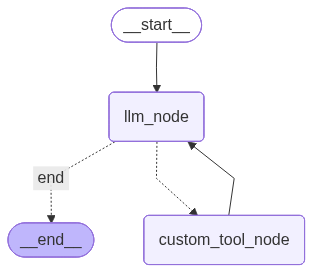

In [338]:
react_graph = graph.compile()

react_graph

### **10. Invoke React Agent Graph**

In [339]:
react_graph.invoke({"messages":[HumanMessage(content="Tell me Todays latest news from India's Forex reserve and after that tell me What is Kolkata weather on 21-05-2026? and after")]})

{'messages': [HumanMessage(content="Tell me Todays latest news from India's Forex reserve and after that tell me What is Kolkata weather on 21-05-2026? and after", additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"query": "India\'s Forex Reserve latest news"}', 'name': 'search_duckduckgo', 'description': None}, 'id': 'call_a049b14ed0e240b7b05df6', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 319, 'total_tokens': 344}, 'model_name': 'Qwen/Qwen2.5-72B-Instruct', 'system_fingerprint': '', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e6445-d95d-7261-abf8-d9771f15776c-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': "India's Forex Reserve latest news"}, 'id': 'call_a049b14ed0e240b7b05df6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 319, 'output_tokens': 25, 'total_tokens': 344}),
  Tool